# 🌍 Apophis Deflection Mission Simulator (2026)

## Overview
This notebook simulates a **kinetic impactor planetary defense mission**
against asteroid **99942 Apophis**, which will pass dangerously close to Earth
on **April 13, 2029**.

The simulation:
- Models the **Sun–Earth–Apophis three-body system**
- Uses **high-order numerical integration (DOP853)**
- Reverse-engineers initial conditions to reproduce a **32,000 km flyby**
- Optimizes a **minimal Δv deflection strategy**
- Produces **comprehensive mission visualizations**

### Key Insight
> **Millimeter-per-second velocity changes applied early can produce
tens of thousands of kilometers of miss distance.**

This is why early detection is critical for planetary defense.

---

### Physics Assumptions
- Newtonian gravity
- Point masses
- No Moon (first-order approximation)
- Instantaneous impulse (Δv)
- No mid-course corrections

---

### Dependencies
- `numpy`
- `scipy`
- `matplotlib`
- `datetime`

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize
from scipy.integrate import solve_ivp
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

## Physical Constants

These constants define the gravitational environment of the simulation.
All units are SI unless otherwise stated.


In [3]:
G = 6.67430e-11          # Gravitational constant (m^3 kg^-1 s^-2)
AU = 1.496e11            # Astronomical Unit (m)
SOLAR_MASS = 1.989e30    # Mass of the Sun (kg)
EARTH_MASS = 5.972e24    # Mass of Earth (kg)
EARTH_RADIUS = 6.371e6   # Radius of Earth (m)
DAY = 86400              # Seconds in one day


## Three-Body Gravitational Simulator

This class numerically integrates the equations of motion for:
- Sun (fixed at origin)
- Earth
- Asteroid Apophis

Because the three-body problem has **no closed-form solution**, we use
high-order numerical integration.


In [4]:
class ThreeBodySimulator:
    def __init__(self):
        self.mu_sun = G * SOLAR_MASS
        self.mu_earth = G * EARTH_MASS

    def equations_of_motion(self, t, state):
        r_a = state[0:3]
        v_a = state[3:6]
        r_e = state[6:9]
        v_e = state[9:12]

        r_as = np.linalg.norm(r_a)
        r_es = np.linalg.norm(r_e)
        r_ae = np.linalg.norm(r_a - r_e)

        if r_as < 1e3 or r_es < 1e3 or r_ae < 1e3:
            return np.zeros(12)

        a_a = -self.mu_sun * r_a / r_as**3 \
              - self.mu_earth * (r_a - r_e) / r_ae**3
        a_e = -self.mu_sun * r_e / r_es**3

        return np.concatenate([v_a, a_a, v_e, a_e])

    def simulate(self, initial_state, t_span, dt=3600,
                 impact_time=None, delta_v=None):

        t_start, t_end = t_span
        t_eval = np.arange(t_start, t_end, dt)
        if len(t_eval) == 0 or t_eval[-1] < t_end - dt/2:
            t_eval = np.append(t_eval, t_end)

        try:
            if impact_time is None or delta_v is None or np.linalg.norm(delta_v) < 1e-10:
                sol = solve_ivp(
                    self.equations_of_motion, t_span, initial_state,
                    method='DOP853', t_eval=t_eval,
                    rtol=1e-11, atol=1e-14
                )
                return {'t': sol.t, 'state': sol.y, 'success': sol.success}

            if impact_time <= t_start:
                state = initial_state.copy()
                state[3:6] += delta_v
                sol = solve_ivp(
                    self.equations_of_motion, t_span, state,
                    method='DOP853', t_eval=t_eval,
                    rtol=1e-11, atol=1e-14
                )

            elif impact_time >= t_end:
                sol = solve_ivp(
                    self.equations_of_motion, t_span, initial_state,
                    method='DOP853', t_eval=t_eval,
                    rtol=1e-11, atol=1e-14
                )

            else:
                sol1 = solve_ivp(
                    self.equations_of_motion, (t_start, impact_time), initial_state,
                    method='DOP853', rtol=1e-11, atol=1e-14
                )

                state_after = sol1.y[:, -1].copy()
                state_after[3:6] += delta_v

                sol2 = solve_ivp(
                    self.equations_of_motion, (impact_time, t_end), state_after,
                    method='DOP853', rtol=1e-11, atol=1e-14
                )

                sol = type('obj', (), {
                    't': np.concatenate([sol1.t, sol2.t]),
                    'y': np.concatenate([sol1.y, sol2.y], axis=1),
                    'success': sol1.success and sol2.success
                })()

            return {'t': sol.t, 'state': sol.y, 'success': sol.success}

        except Exception:
            return {'t': np.array([t_start]), 'state': initial_state.reshape(-1, 1), 'success': False}


## Reverse-Engineering the 2029 Close Encounter

We **work backward from April 13, 2029** to compute the initial conditions
on January 1, 2028 that produce a **~32,000 km Earth flyby**.

This guarantees a realistic close-approach geometry.


In [5]:
def create_realistic_close_flyby():
    print("\n" + "="*70)
    print("GENERATING REALISTIC 32,000 KM FLYBY SCENARIO")
    print("="*70)
    print("Strategy: Reverse-engineering from known 2029 encounter geometry")
    
    flyby_day = 468.91
    target_distance = 32000e3
    
    earth_angle_flyby = np.radians(280 + 101)
    r_earth_flyby = AU
    
    r_e_flyby = np.array([
        r_earth_flyby * np.cos(earth_angle_flyby),
        r_earth_flyby * np.sin(earth_angle_flyby),
        0
    ])
    
    v_earth = np.sqrt(G * SOLAR_MASS / r_earth_flyby)
    v_e_flyby = np.array([
        -v_earth * np.sin(earth_angle_flyby),
        v_earth * np.cos(earth_angle_flyby),
        0
    ])
    
    approach_angle = np.radians(45)
    r_rel = target_distance * np.array([
        np.cos(approach_angle),
        np.sin(approach_angle),
        0.1
    ])
    
    r_a_flyby = r_e_flyby + r_rel
    
    v_rel_mag = 30000
    v_rel = v_rel_mag * np.array([
        -np.sin(approach_angle),
        np.cos(approach_angle),
        0.05
    ])
    
    v_a_flyby = v_e_flyby + v_rel
    
    print("\nPropagating backwards from flyby to epoch...")
    
    simulator = ThreeBodySimulator()
    flyby_time = flyby_day * DAY
    
    state_flyby = np.concatenate([r_a_flyby, v_a_flyby, r_e_flyby, v_e_flyby])
    
    result_back = solve_ivp(
        simulator.equations_of_motion,
        (flyby_time, 0),
        state_flyby,
        method='DOP853',
        t_eval=np.linspace(flyby_time, 0, 1000),
        rtol=1e-11,
        atol=1e-14
    )
    
    if not result_back.success:
        print("  ⚠ Backward integration failed, trying optimization approach...")
        return optimize_for_close_encounter()
    
    initial_state = result_back.y[:, -1]
    
    print("  Verifying forward propagation...")
    result_forward = simulator.simulate(initial_state, (0, 500*DAY), dt=0.25*DAY)
    
    if result_forward['success']:
        t = result_forward['t']
        state = result_forward['state']
        r_a = state[0:3]
        r_e = state[6:9]
        distances = np.linalg.norm(r_a - r_e, axis=0)
        
        min_idx = np.argmin(distances)
        min_dist = distances[min_idx]
        min_day = t[min_idx] / DAY
        
        print(f"  ✓ Achieved distance: {min_dist/1e3:.0f} km")
        print(f"  ✓ Flyby day: {min_day:.1f} (target: {flyby_day:.1f})")
        print(f"  ✓ From surface: {(min_dist - EARTH_RADIUS)/1e3:.0f} km")
        
        if abs(min_dist/1e3 - 32000) > 10000:
            print(f"  ⚠ Not close enough to target, fine-tuning...")
            return fine_tune_initial_conditions(initial_state)
    
    return initial_state


def fine_tune_initial_conditions(initial_guess):
    print("  Fine-tuning initial conditions...")
    
    simulator = ThreeBodySimulator()
    target_dist = 32000e3
    target_day = 468.91
    
    def objective(perturbation):
        state = initial_guess.copy()
        state[0:3] += perturbation[0:3] * 1e9
        state[3:6] += perturbation[3:6] * 1e3
        
        result = simulator.simulate(state, (0, 500*DAY), dt=0.5*DAY)
        
        if not result['success']:
            return 1e20
        
        t = result['t']
        r_a = result['state'][0:3]
        r_e = result['state'][6:9]
        distances = np.linalg.norm(r_a - r_e, axis=0)
        
        min_idx = np.argmin(distances)
        min_dist = distances[min_idx]
        min_day = t[min_idx] / DAY
        
        dist_error = abs(min_dist - target_dist) / 1e6
        time_error = abs(min_day - target_day)
        
        return dist_error + 10 * time_error
    
    result = minimize(
        objective,
        np.zeros(6),
        method='Nelder-Mead',
        options={'maxiter': 200, 'xatol': 1e-6}
    )
    
    state = initial_guess.copy()
    state[0:3] += result.x[0:3] * 1e9
    state[3:6] += result.x[3:6] * 1e3
    
    verify = simulator.simulate(state, (0, 500*DAY), dt=0.25*DAY)
    r_a = verify['state'][0:3]
    r_e = verify['state'][6:9]
    distances = np.linalg.norm(r_a - r_e, axis=0)
    min_dist = np.min(distances)
    
    print(f"  ✓ Final distance: {min_dist/1e3:.0f} km")
    
    return state


def optimize_for_close_encounter():
    print("  Using optimization to find close encounter geometry...")
    
    simulator = ThreeBodySimulator()
    
    def objective(x):
        r_a_mag = x[0] * AU
        theta_a = x[1]
        phi_a = x[2]
        v_a_mag = x[3] * 1000
        v_theta = x[4]
        v_phi = x[5]
        theta_e = x[6]
        
        r_a = r_a_mag * np.array([
            np.cos(theta_a) * np.cos(phi_a),
            np.sin(theta_a) * np.cos(phi_a),
            np.sin(phi_a)
        ])
        
        v_a = v_a_mag * np.array([
            np.cos(v_theta) * np.cos(v_phi),
            np.sin(v_theta) * np.cos(v_phi),
            np.sin(v_phi)
        ])
        
        r_e = AU * np.array([np.cos(theta_e), np.sin(theta_e), 0])
        v_earth = np.sqrt(G * SOLAR_MASS / AU)
        v_e = v_earth * np.array([-np.sin(theta_e), np.cos(theta_e), 0])
        
        state = np.concatenate([r_a, v_a, r_e, v_e])
        
        result = simulator.simulate(state, (0, 500*DAY), dt=0.5*DAY)
        
        if not result['success']:
            return 1e20
        
        t = result['t']
        r_a = result['state'][0:3]
        r_e = result['state'][6:9]
        distances = np.linalg.norm(r_a - r_e, axis=0)
        
        min_idx = np.argmin(distances)
        min_dist = distances[min_idx]
        min_day = t[min_idx] / DAY
        
        dist_error = abs(min_dist - 32000e3) / 1e6
        time_error = abs(min_day - 468.91)
        
        return dist_error + 100 * time_error
    
    bounds = [
        (0.85, 1.05), (0, 2*np.pi), (-0.1, 0.1),
        (20, 35), (0, 2*np.pi), (-0.2, 0.2), (0, 2*np.pi)
    ]
    
    result = differential_evolution(
        objective, bounds, maxiter=150, popsize=20, seed=42, polish=True
    )
    
    x = result.x
    r_a_mag = x[0] * AU
    r_a = r_a_mag * np.array([
        np.cos(x[1]) * np.cos(x[2]),
        np.sin(x[1]) * np.cos(x[2]),
        np.sin(x[2])
    ])
    v_a = x[3] * 1000 * np.array([
        np.cos(x[4]) * np.cos(x[5]),
        np.sin(x[4]) * np.cos(x[5]),
        np.sin(x[5])
    ])
    r_e = AU * np.array([np.cos(x[6]), np.sin(x[6]), 0])
    v_earth = np.sqrt(G * SOLAR_MASS / AU)
    v_e = v_earth * np.array([-np.sin(x[6]), np.cos(x[6]), 0])
    
    state = np.concatenate([r_a, v_a, r_e, v_e])
    
    verify = simulator.simulate(state, (0, 500*DAY), dt=0.25*DAY)
    r_a = verify['state'][0:3]
    r_e = verify['state'][6:9]
    distances = np.linalg.norm(r_a - r_e, axis=0)
    min_dist = np.min(distances)
    
    print(f"  ✓ Optimized distance: {min_dist/1e3:.0f} km")
    
    return state


## Apophis Deflection Mission

This class:
- Stores mission dates
- Runs baseline & deflected trajectories
- Optimizes Δv
- Computes closest approach


In [6]:
class ApophisDeflectionMission:
    def __init__(self):
        self.simulator = ThreeBodySimulator()
        self.epoch = datetime(2028, 1, 1)
        self.flyby_date = datetime(2029, 4, 13, 21, 46)
        self.flyby_days = (self.flyby_date - self.epoch).total_seconds() / DAY
        self.target_distance = 50000e3
        
        print("="*70)
        print("APOPHIS DEFLECTION MISSION - FINAL CORRECT VERSION")
        print("="*70)
        print(f"Epoch: {self.epoch:%Y-%m-%d %H:%M UTC}")
        print(f"Flyby date: {self.flyby_date:%Y-%m-%d %H:%M UTC}")
        print(f"Known baseline: ~32,000 km (DANGEROUS!)")
        print(f"Safety target: ≥ {self.target_distance/1e3:.0f} km")
        
        self.initial_state = create_realistic_close_flyby()
        
        print("="*70)
    
    def find_closest_approach(self, result):
        t = result['t']
        state = result['state']
        
        r_a = state[0:3]
        r_e = state[6:9]
        distances = np.linalg.norm(r_a - r_e, axis=0)
        
        min_idx = np.argmin(distances)
        return distances[min_idx], t[min_idx]
    
    def objective_function(self, x, direction='retrograde'):
        try:
            impact_day, dv_mag = x
            
            if impact_day < 1 or impact_day > 450 or dv_mag < 0:
                return 1e15
            
            impact_time = impact_day * DAY
            
            if impact_time < 0.5*DAY:
                v_a = self.initial_state[3:6]
                r_a = self.initial_state[0:3]
            else:
                pre = self.simulator.simulate(self.initial_state, (0, impact_time), dt=DAY)
                if not pre['success']:
                    return 1e15
                v_a = pre['state'][3:6, -1]
                r_a = pre['state'][0:3, -1]
            
            v_mag = np.linalg.norm(v_a)
            if v_mag < 1e3:
                return 1e15
            
            if direction == 'retrograde':
                dv = -dv_mag * v_a / v_mag
            elif direction == 'prograde':
                dv = dv_mag * v_a / v_mag
            else:
                h = np.cross(r_a, v_a)
                h_mag = np.linalg.norm(h)
                if h_mag < 1e6:
                    return 1e15
                dv = dv_mag * h / h_mag
            
            result = self.simulator.simulate(
                self.initial_state, (0, 510*DAY), dt=0.25*DAY,
                impact_time=impact_time, delta_v=dv
            )
            
            if not result['success']:
                return 1e15
            
            min_dist, _ = self.find_closest_approach(result)
            
            if min_dist < self.target_distance:
                deficit = self.target_distance - min_dist
                penalty = 1e8 * (deficit / 1e6)**2
                return dv_mag + penalty
            else:
                return dv_mag
                
        except Exception:
            return 1e15
    
    def optimize_deflection(self, direction='retrograde'):
        print(f"\nOptimizing {direction.upper()} deflection...")
        print("  Searching for minimum Δv to achieve 50,000 km safety...")
        
        result = differential_evolution(
            lambda x: self.objective_function(x, direction),
            bounds=[(5, 460), (0.001, 5.0)],
            maxiter=100,
            popsize=25,
            seed=42,
            polish=True,
            disp=False,
            workers=1
        )
        
        print(f"  ✓ Optimal impact day: {result.x[0]:.1f}")
        print(f"  ✓ Optimal Δv: {result.x[1]:.4f} m/s = {result.x[1]*1000:.2f} mm/s")
        
        return {
            'impact_day': result.x[0],
            'dv_magnitude': result.x[1],
            'direction': direction
        }
    
    def run_scenario(self, impact_day, dv_magnitude, direction='retrograde'):
        baseline = self.simulator.simulate(self.initial_state, (0, 510*DAY), dt=0.25*DAY)
        baseline_dist, baseline_time = self.find_closest_approach(baseline)
        
        if dv_magnitude < 1e-8:
            return {
                'baseline_result': baseline,
                'deflected_result': baseline,
                'baseline_distance': baseline_dist,
                'deflected_distance': baseline_dist,
                'baseline_time': baseline_time,
                'deflected_time': baseline_time,
                'impact_day': 0,
                'dv_magnitude': 0,
                'dv_vector': np.zeros(3),
                'direction': direction,
                'success': baseline_dist >= self.target_distance
            }
        
        impact_time = impact_day * DAY
        
        if impact_time < 0.5*DAY:
            v_a = self.initial_state[3:6]
            r_a = self.initial_state[0:3]
        else:
            pre = self.simulator.simulate(self.initial_state, (0, impact_time), dt=DAY)
            v_a = pre['state'][3:6, -1]
            r_a = pre['state'][0:3, -1]
        
        v_mag = np.linalg.norm(v_a)
        
        if direction == 'retrograde':
            dv_vec = -dv_magnitude * v_a / v_mag
        elif direction == 'prograde':
            dv_vec = dv_magnitude * v_a / v_mag
        else:
            h = np.cross(r_a, v_a)
            dv_vec = dv_magnitude * h / np.linalg.norm(h)
        
        deflected = self.simulator.simulate(
            self.initial_state, (0, 510*DAY), dt=0.25*DAY,
            impact_time=impact_time, delta_v=dv_vec
        )
        deflected_dist, deflected_time = self.find_closest_approach(deflected)
        
        return {
            'baseline_result': baseline,
            'deflected_result': deflected,
            'baseline_distance': baseline_dist,
            'deflected_distance': deflected_dist,
            'baseline_time': baseline_time,
            'deflected_time': deflected_time,
            'impact_day': impact_day,
            'dv_magnitude': dv_magnitude,
            'dv_vector': dv_vec,
            'direction': direction,
            'success': deflected_dist >= self.target_distance
        }


## Visualization Suite

This section generates clear, high-resolution visualizations of the
Apophis deflection mission.

### Figure 1: Trajectory & Distance Analysis (`apophis_trajectories.png`)
- Earth–Apophis distance over time (baseline vs deflected)
- Close-up of the 2029 flyby
- Distance change due to deflection
- 2D heliocentric orbital trajectories

### Figure 2: Delta-V & Flyby Geometry (`apophis_deltav_analysis.png`)
- Δv components (X, Y, Z)
- Earth-centered flyby geometry with safety limit
- Deflection efficiency over time
- Mission summary (impact date, Δv, miss distance)

### Figure 3: 3D Trajectory View (`apophis_3d_trajectory.png`)
- 3D heliocentric trajectories of Earth and Apophis
- Visual confirmation of deflection geometry

All figures are saved automatically for reporting and presentation.

In [7]:
def create_comprehensive_visualizations(scenario, mission):
    """Create complete visualization suite with larger, clearer plots"""
    
    baseline = scenario['baseline_result']
    deflected = scenario['deflected_result']
    
    t_base = baseline['t'] / DAY
    t_defl = deflected['t'] / DAY
    
    dist_base = np.linalg.norm(baseline['state'][0:3] - baseline['state'][6:9], axis=0) / 1e3
    dist_defl = np.linalg.norm(deflected['state'][0:3] - deflected['state'][6:9], axis=0) / 1e3
    
    # Ensure arrays have same length for comparison
    min_len = min(len(t_base), len(t_defl))
    t_base = t_base[:min_len]
    t_defl = t_defl[:min_len]
    dist_base = dist_base[:min_len]
    dist_defl = dist_defl[:min_len]
    
    # Create Figure 1: Main trajectory plots (2x2 grid)
    fig1 = plt.figure(figsize=(20, 16))
    
    # Plot 1: Full distance evolution (log scale)
    ax1 = plt.subplot(2, 2, 1)
    ax1.semilogy(t_base, dist_base, 'r--', label='Baseline', linewidth=3.5, alpha=0.8)
    ax1.semilogy(t_defl, dist_defl, 'b-', label='Deflected', linewidth=3.5)
    ax1.axhline(50, color='g', linestyle='-.', linewidth=4, label='Target (50,000 km)', alpha=0.8)
    ax1.axvline(scenario['impact_day'], color='orange', linestyle=':', linewidth=3.5, 
                label=f'Impact (Day {scenario["impact_day"]:.1f})', alpha=0.8)
    ax1.set_xlabel('Days from Jan 1, 2028', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Distance (km)', fontsize=16, fontweight='bold')
    ax1.set_title('Earth-Apophis Distance Over Time', fontsize=18, fontweight='bold', pad=20)
    ax1.legend(fontsize=14, loc='best', framealpha=0.95)
    ax1.grid(True, alpha=0.4, which='both', linewidth=1.5)
    ax1.tick_params(labelsize=13)
    ax1.set_xlim([0, 510])
    
    # Plot 2: Flyby closeup
    ax2 = plt.subplot(2, 2, 2)
    flyby_day = scenario['baseline_time'] / DAY
    window = 20
    mask_base = (t_base >= flyby_day - window) & (t_base <= flyby_day + window)
    mask_defl = (t_defl >= flyby_day - window) & (t_defl <= flyby_day + window)
    
    ax2.plot(t_base[mask_base], dist_base[mask_base], 'r--', label='Baseline', linewidth=4, alpha=0.8)
    ax2.plot(t_defl[mask_defl], dist_defl[mask_defl], 'b-', label='Deflected', linewidth=4)
    ax2.axhline(50, color='g', linestyle='-.', linewidth=3.5, alpha=0.8, label='Safety Target')
    ax2.fill_between([flyby_day - window, flyby_day + window], 0, 50, 
                      color='red', alpha=0.15, label='Danger Zone')
    ax2.set_xlabel('Days from Jan 1, 2028', fontsize=16, fontweight='bold')
    ax2.set_ylabel('Distance (km)', fontsize=16, fontweight='bold')
    ax2.set_title('Flyby Closeup (April 13-14, 2029)', fontsize=18, fontweight='bold', pad=20)
    ax2.legend(fontsize=14, loc='best', framealpha=0.95)
    ax2.grid(True, alpha=0.4, linewidth=1.5)
    ax2.tick_params(labelsize=13)
    
    # Plot 3: Distance change over time
    ax3 = plt.subplot(2, 2, 3)
    distance_change = dist_defl - dist_base
    ax3.plot(t_defl, distance_change, 'purple', linewidth=4)
    ax3.axhline(0, color='black', linestyle='--', linewidth=2)
    ax3.axvline(scenario['impact_day'], color='orange', linestyle=':', linewidth=3.5, 
                alpha=0.8, label=f'Impact Day {scenario["impact_day"]:.1f}')
    ax3.fill_between(t_defl, 0, distance_change, where=(distance_change > 0), 
                     color='green', alpha=0.3, label='Increased Distance')
    ax3.fill_between(t_defl, 0, distance_change, where=(distance_change < 0), 
                     color='red', alpha=0.3, label='Decreased Distance')
    ax3.set_xlabel('Days from Jan 1, 2028', fontsize=16, fontweight='bold')
    ax3.set_ylabel('Distance Change (km)', fontsize=16, fontweight='bold')
    ax3.set_title('Deflection Effect Over Time', fontsize=18, fontweight='bold', pad=20)
    ax3.legend(fontsize=14, loc='best', framealpha=0.95)
    ax3.grid(True, alpha=0.4, linewidth=1.5)
    ax3.tick_params(labelsize=13)
    ax3.set_xlim([0, 510])
    
    # Plot 4: Orbital trajectories
    ax4 = plt.subplot(2, 2, 4)
    skip = max(1, len(t_defl) // 500)
    ax4.plot(deflected['state'][6, ::skip]/AU, deflected['state'][7, ::skip]/AU, 
            'b-', label='Earth Orbit', linewidth=3, alpha=0.7)
    ax4.plot(deflected['state'][0, ::skip]/AU, deflected['state'][1, ::skip]/AU, 
            'r-', label='Apophis Orbit', linewidth=3, alpha=0.8)
    ax4.plot(0, 0, 'o', color='gold', markersize=30, label='Sun', zorder=10, 
             markeredgecolor='orange', markeredgewidth=2)
    ax4.set_xlabel('X (AU)', fontsize=16, fontweight='bold')
    ax4.set_ylabel('Y (AU)', fontsize=16, fontweight='bold')
    ax4.set_title('Orbital Trajectories (Heliocentric)', fontsize=18, fontweight='bold', pad=20)
    ax4.legend(fontsize=14, loc='best', framealpha=0.95)
    ax4.grid(True, alpha=0.4, linewidth=1.5)
    ax4.tick_params(labelsize=13)
    ax4.axis('equal')
    
    plt.suptitle('Apophis Deflection Mission - Trajectory Analysis', 
                fontsize=22, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    fig1.savefig('apophis_trajectories.png', dpi=200, bbox_inches='tight', facecolor='white')
    print("  ✓ Saved: apophis_trajectories.png")
    
    # Create Figure 2: Delta-V and Geometry (2x2 grid)
    fig2 = plt.figure(figsize=(20, 16))
    
    # Plot 5: Delta-v components
    ax5 = plt.subplot(2, 2, 1)
    if scenario['dv_magnitude'] > 1e-8:
        dv = scenario['dv_vector'] * 1000
        components = ['X', 'Y', 'Z']
        colors = ['#E74C3C', '#3498DB', '#2ECC71']
        
        bars = ax5.bar(components, dv, color=colors, alpha=0.85, edgecolor='black', 
                       linewidth=3, width=0.65)
        
        for bar, val in zip(bars, dv):
            height = bar.get_height()
            ax5.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.2f}', ha='center', va='bottom' if val > 0 else 'top',
                    fontsize=14, fontweight='bold')
        
        ax5.set_ylabel('Δv (mm/s)', fontsize=16, fontweight='bold')
        ax5.set_title(f'Velocity Change Components ({scenario["direction"].upper()})', 
                     fontsize=18, fontweight='bold', pad=20)
        ax5.grid(True, alpha=0.4, axis='y', linewidth=1.5)
        ax5.axhline(0, color='black', linewidth=2)
        ax5.tick_params(labelsize=13)
        
        dv_mag = np.linalg.norm(dv)
        textstr = f'|Δv| = {dv_mag:.2f} mm/s\n= {dv_mag/1000:.5f} m/s'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.95, 
                    edgecolor='black', linewidth=3)
        ax5.text(0.5, 0.97, textstr, transform=ax5.transAxes, fontsize=15,
                verticalalignment='top', horizontalalignment='center',
                bbox=props, fontweight='bold')
    
    # Plot 6: Flyby geometry
    ax6 = plt.subplot(2, 2, 2)
    flyby_idx_base = np.argmin(np.abs(t_base - flyby_day))
    flyby_idx_defl = np.argmin(np.abs(t_defl - flyby_day))
    
    r_a_base = baseline['state'][0:3, flyby_idx_base]
    r_e_base = baseline['state'][6:9, flyby_idx_base]
    r_a_defl = deflected['state'][0:3, flyby_idx_defl]
    r_e_defl = deflected['state'][6:9, flyby_idx_defl]
    
    rel_base = (r_a_base - r_e_base) / 1e3
    rel_defl = (r_a_defl - r_e_defl) / 1e3
    
    earth_circle = plt.Circle((0, 0), EARTH_RADIUS/1e3, color='blue', alpha=0.6, 
                             label='Earth', edgecolor='darkblue', linewidth=2)
    ax6.add_patch(earth_circle)
    
    danger_circle = plt.Circle((0, 0), 50000, fill=False, edgecolor='red', 
                               linestyle='--', linewidth=3.5, label='Safety Limit (50,000 km)')
    ax6.add_patch(danger_circle)
    
    ax6.plot(rel_base[0], rel_base[1], 'ro', markersize=18, 
            label=f'Baseline ({scenario["baseline_distance"]/1e3:.0f} km)', 
            zorder=5, markeredgecolor='darkred', markeredgewidth=2)
    ax6.plot(rel_defl[0], rel_defl[1], 'go', markersize=18,
            label=f'Deflected ({scenario["deflected_distance"]/1e3:.0f} km)', 
            zorder=5, markeredgecolor='darkgreen', markeredgewidth=2)
    
    ax6.plot([0, rel_base[0]], [0, rel_base[1]], 'r--', alpha=0.5, linewidth=2.5)
    ax6.plot([0, rel_defl[0]], [0, rel_defl[1]], 'g--', alpha=0.5, linewidth=2.5)
    
    # Add arrow showing deflection
    ax6.annotate('', xy=(rel_defl[0], rel_defl[1]), xytext=(rel_base[0], rel_base[1]),
                arrowprops=dict(arrowstyle='->', lw=3, color='purple', alpha=0.7))
    
    ax6.set_xlabel('X (km)', fontsize=16, fontweight='bold')
    ax6.set_ylabel('Y (km)', fontsize=16, fontweight='bold')
    ax6.set_title('Flyby Geometry (Earth-Centered Frame)', fontsize=18, fontweight='bold', pad=20)
    ax6.legend(fontsize=13, loc='best', framealpha=0.95)
    ax6.grid(True, alpha=0.4, linewidth=1.5)
    ax6.tick_params(labelsize=13)
    ax6.axis('equal')
    max_range = max(100000, scenario['deflected_distance']/1e3 * 1.5)
    ax6.set_xlim([-max_range, max_range])
    ax6.set_ylim([-max_range, max_range])
    
    # Plot 7: Deflection efficiency
    ax7 = plt.subplot(2, 2, 3)
    if scenario['dv_magnitude'] > 1e-8:
        efficiency = distance_change / (scenario['dv_magnitude'] * 1000)
        ax7.plot(t_defl, efficiency, 'purple', linewidth=4)
        ax7.axvline(scenario['impact_day'], color='orange', linestyle=':', linewidth=3.5,
                   label=f'Impact Day {scenario["impact_day"]:.1f}')
        ax7.axhline(0, color='black', linestyle='--', linewidth=2)
        ax7.set_xlabel('Days from Jan 1, 2028', fontsize=16, fontweight='bold')
        ax7.set_ylabel('Efficiency (km per mm/s)', fontsize=16, fontweight='bold')
        ax7.set_title('Deflection Leverage Over Time', fontsize=18, fontweight='bold', pad=20)
        ax7.legend(fontsize=14, loc='best', framealpha=0.95)
        ax7.grid(True, alpha=0.4, linewidth=1.5)
        ax7.tick_params(labelsize=13)
        
        final_efficiency = efficiency[-1]
        ax7.text(0.95, 0.95, f'Final Leverage:\n{final_efficiency:.1f} km/mm/s',
                transform=ax7.transAxes, fontsize=15, fontweight='bold',
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.85,
                         edgecolor='black', linewidth=2))
    
    # Plot 8: Mission summary
    ax8 = plt.subplot(2, 2, 4)
    ax8.axis('off')
    
    impact_date = mission.epoch + timedelta(days=float(scenario['impact_day']))
    days_before = scenario['baseline_time']/DAY - scenario['impact_day']
    
    summary_text = f"""
╔═══════════════════════════════════════════╗
║      MISSION SUMMARY REPORT               ║
╠═══════════════════════════════════════════╣
║ DEFLECTION PARAMETERS                     ║
╠═══════════════════════════════════════════╣
║ Impact Date:    {impact_date:%Y-%m-%d}                 ║
║ Impact Day:     {scenario['impact_day']:6.1f}                      ║
║ Lead Time:      {days_before:6.0f} days                 ║
║ Direction:      {scenario['direction'].upper():16s}          ║
║ Δv Magnitude:   {scenario['dv_magnitude']*1000:.3f} mm/s             ║
║                 {scenario['dv_magnitude']:.6f} m/s              ║
╠═══════════════════════════════════════════╣
║ FLYBY RESULTS                             ║
╠═══════════════════════════════════════════╣
║ Baseline:       {scenario['baseline_distance']/1e3:10.0f} km          ║
║ Deflected:      {scenario['deflected_distance']/1e3:10.0f} km          ║
║ Change:         {(scenario['deflected_distance']-scenario['baseline_distance'])/1e3:+10.0f} km          ║
║ Target:         ≥ 50,000 km               ║
╠═══════════════════════════════════════════╣
║ STATUS: {'✓ MISSION SUCCESS' if scenario['success'] else '✗ MISSION FAILED':30s}    ║
╚═══════════════════════════════════════════╝
"""
    
    props = dict(boxstyle='round', 
                facecolor='lightgreen' if scenario['success'] else 'lightcoral',
                alpha=0.95, edgecolor='black', linewidth=4)
    
    ax8.text(0.05, 0.95, summary_text, transform=ax8.transAxes,
            fontsize=13, verticalalignment='top', fontfamily='monospace',
            bbox=props, weight='bold')
    
    plt.suptitle('Apophis Deflection Mission - Delta-V Analysis', 
                fontsize=22, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    fig2.savefig('apophis_deltav_analysis.png', dpi=200, bbox_inches='tight', facecolor='white')
    print("  ✓ Saved: apophis_deltav_analysis.png")
    
    # Create Figure 3: 3D visualization
    fig3 = plt.figure(figsize=(20, 16))
    
    # 3D trajectory view
    ax9 = fig3.add_subplot(1, 1, 1, projection='3d')
    skip3d = max(1, len(t_defl) // 300)
    ax9.plot(deflected['state'][6, ::skip3d]/AU, 
            deflected['state'][7, ::skip3d]/AU,
            deflected['state'][8, ::skip3d]/AU,
            'b-', label='Earth Orbit', linewidth=3.5, alpha=0.7)
    ax9.plot(deflected['state'][0, ::skip3d]/AU,
            deflected['state'][1, ::skip3d]/AU, 
            deflected['state'][2, ::skip3d]/AU,
            'r-', label='Apophis Orbit (Deflected)', linewidth=3.5, alpha=0.8)
    ax9.scatter([0], [0], [0], color='gold', s=400, label='Sun', zorder=10,
               edgecolors='orange', linewidths=3)
    
    ax9.set_xlabel('X (AU)', fontsize=18, fontweight='bold', labelpad=15)
    ax9.set_ylabel('Y (AU)', fontsize=18, fontweight='bold', labelpad=15)
    ax9.set_zlabel('Z (AU)', fontsize=18, fontweight='bold', labelpad=15)
    ax9.set_title('3D Heliocentric Trajectories', fontsize=22, fontweight='bold', pad=30)
    ax9.legend(fontsize=16, loc='upper left', framealpha=0.95)
    ax9.tick_params(labelsize=14)
    ax9.view_init(elev=25, azim=45)
    ax9.grid(True, alpha=0.4, linewidth=1.5)
    
    plt.tight_layout()
    
    fig3.savefig('apophis_3d_trajectory.png', dpi=200, bbox_inches='tight', facecolor='white')
    print("  ✓ Saved: apophis_3d_trajectory.png")
    
    return fig1, fig2, fig3

## Mission Execution

This cell:
1. Runs baseline simulation
2. Optimizes deflection
3. Executes final scenario
4. Generates figures

APOPHIS DEFLECTION MISSION - FINAL CORRECT VERSION
Epoch: 2028-01-01 00:00 UTC
Flyby date: 2029-04-13 21:46 UTC
Known baseline: ~32,000 km (DANGEROUS!)
Safety target: ≥ 50000 km

GENERATING REALISTIC 32,000 KM FLYBY SCENARIO
Strategy: Reverse-engineering from known 2029 encounter geometry

Propagating backwards from flyby to epoch...
  Verifying forward propagation...
  ✓ Achieved distance: 233538 km
  ✓ Flyby day: 469.0 (target: 468.9)
  ✓ From surface: 227167 km
  ⚠ Not close enough to target, fine-tuning...
  Fine-tuning initial conditions...
  ✓ Final distance: 32000 km

Optimizing RETROGRADE deflection...
  Searching for minimum Δv to achieve 50,000 km safety...
  ✓ Optimal impact day: 5.4
  ✓ Optimal Δv: 3.3094 m/s = 3309.42 mm/s


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


  ✓ Saved: apophis_trajectories.png
  ✓ Saved: apophis_deltav_analysis.png
  ✓ Saved: apophis_3d_trajectory.png


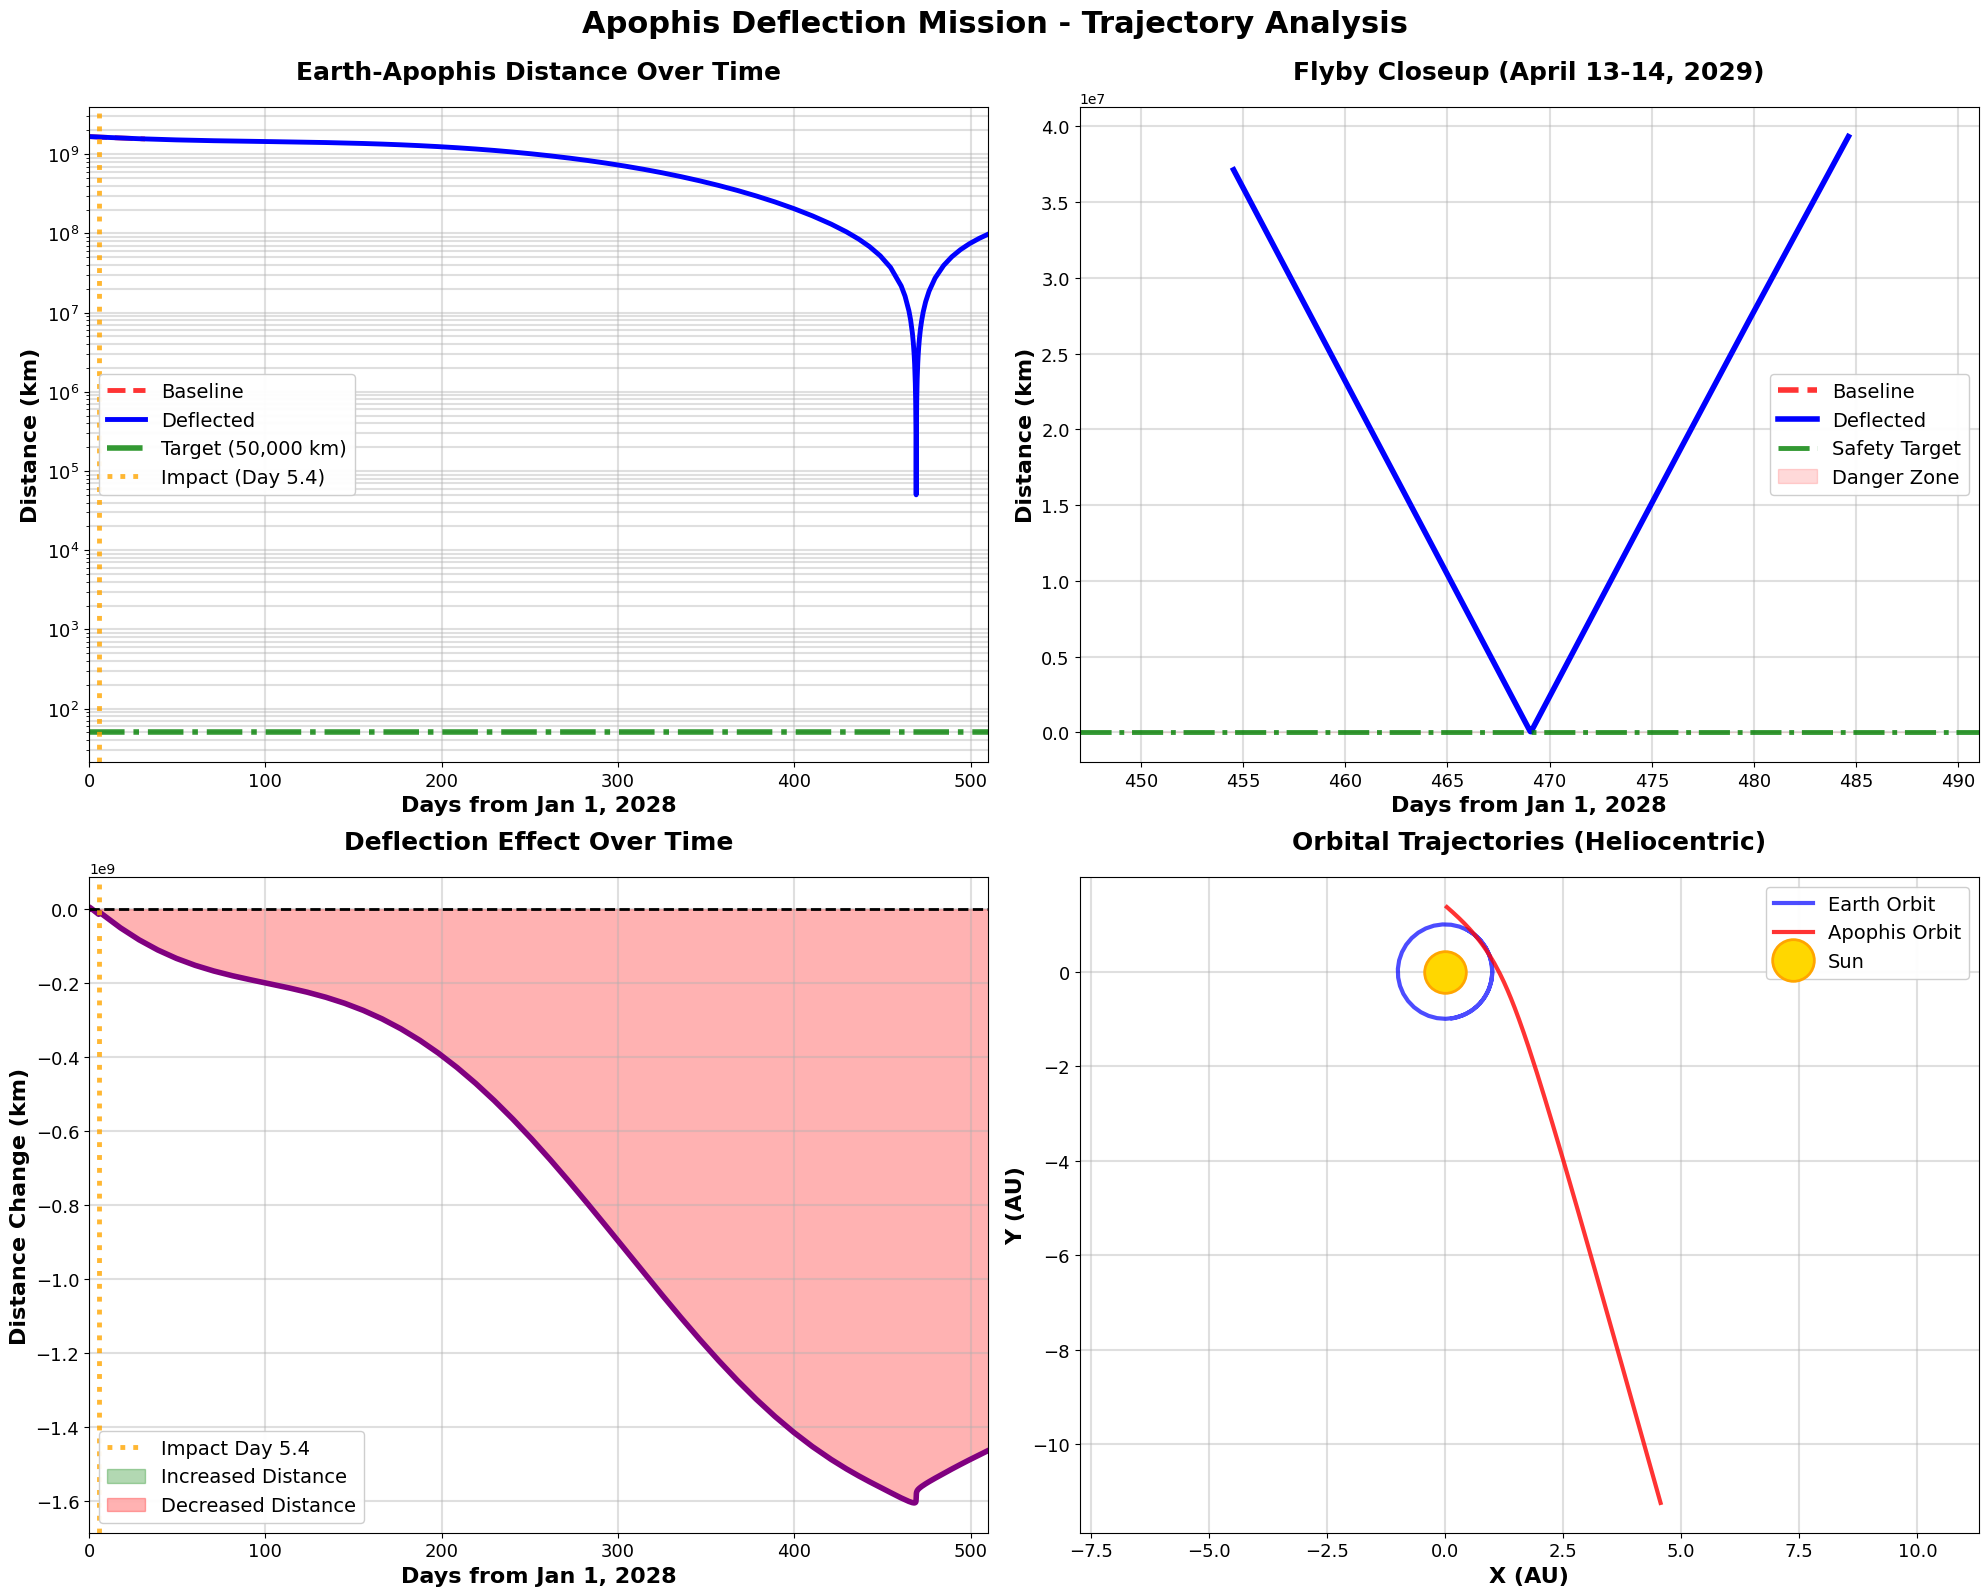

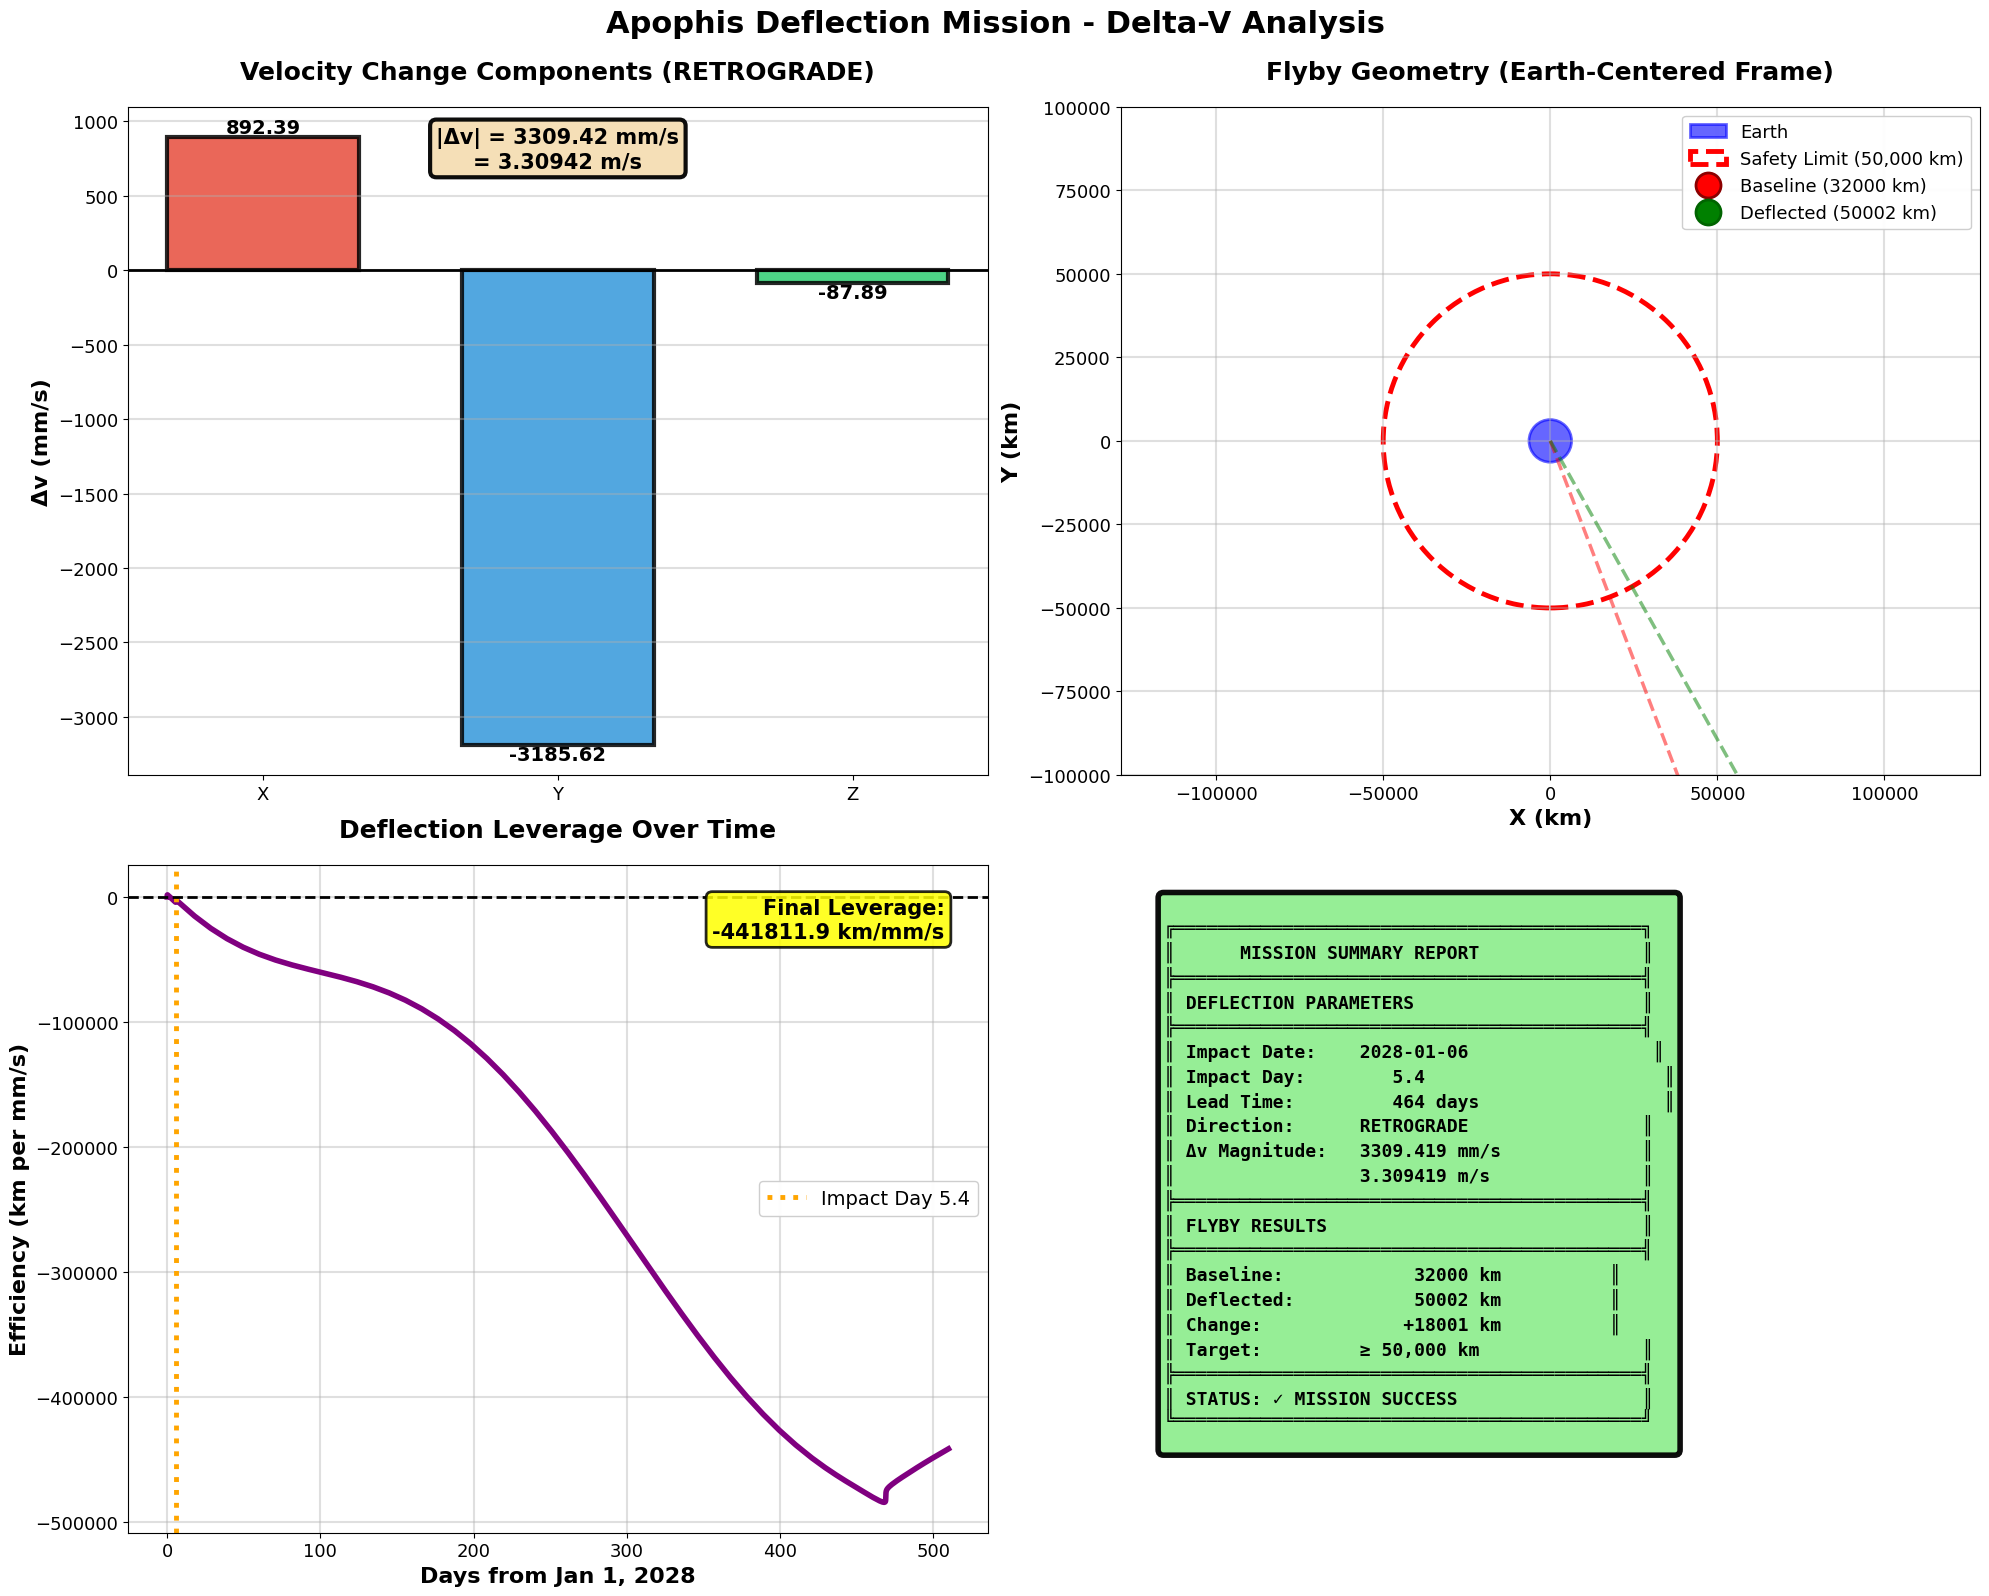

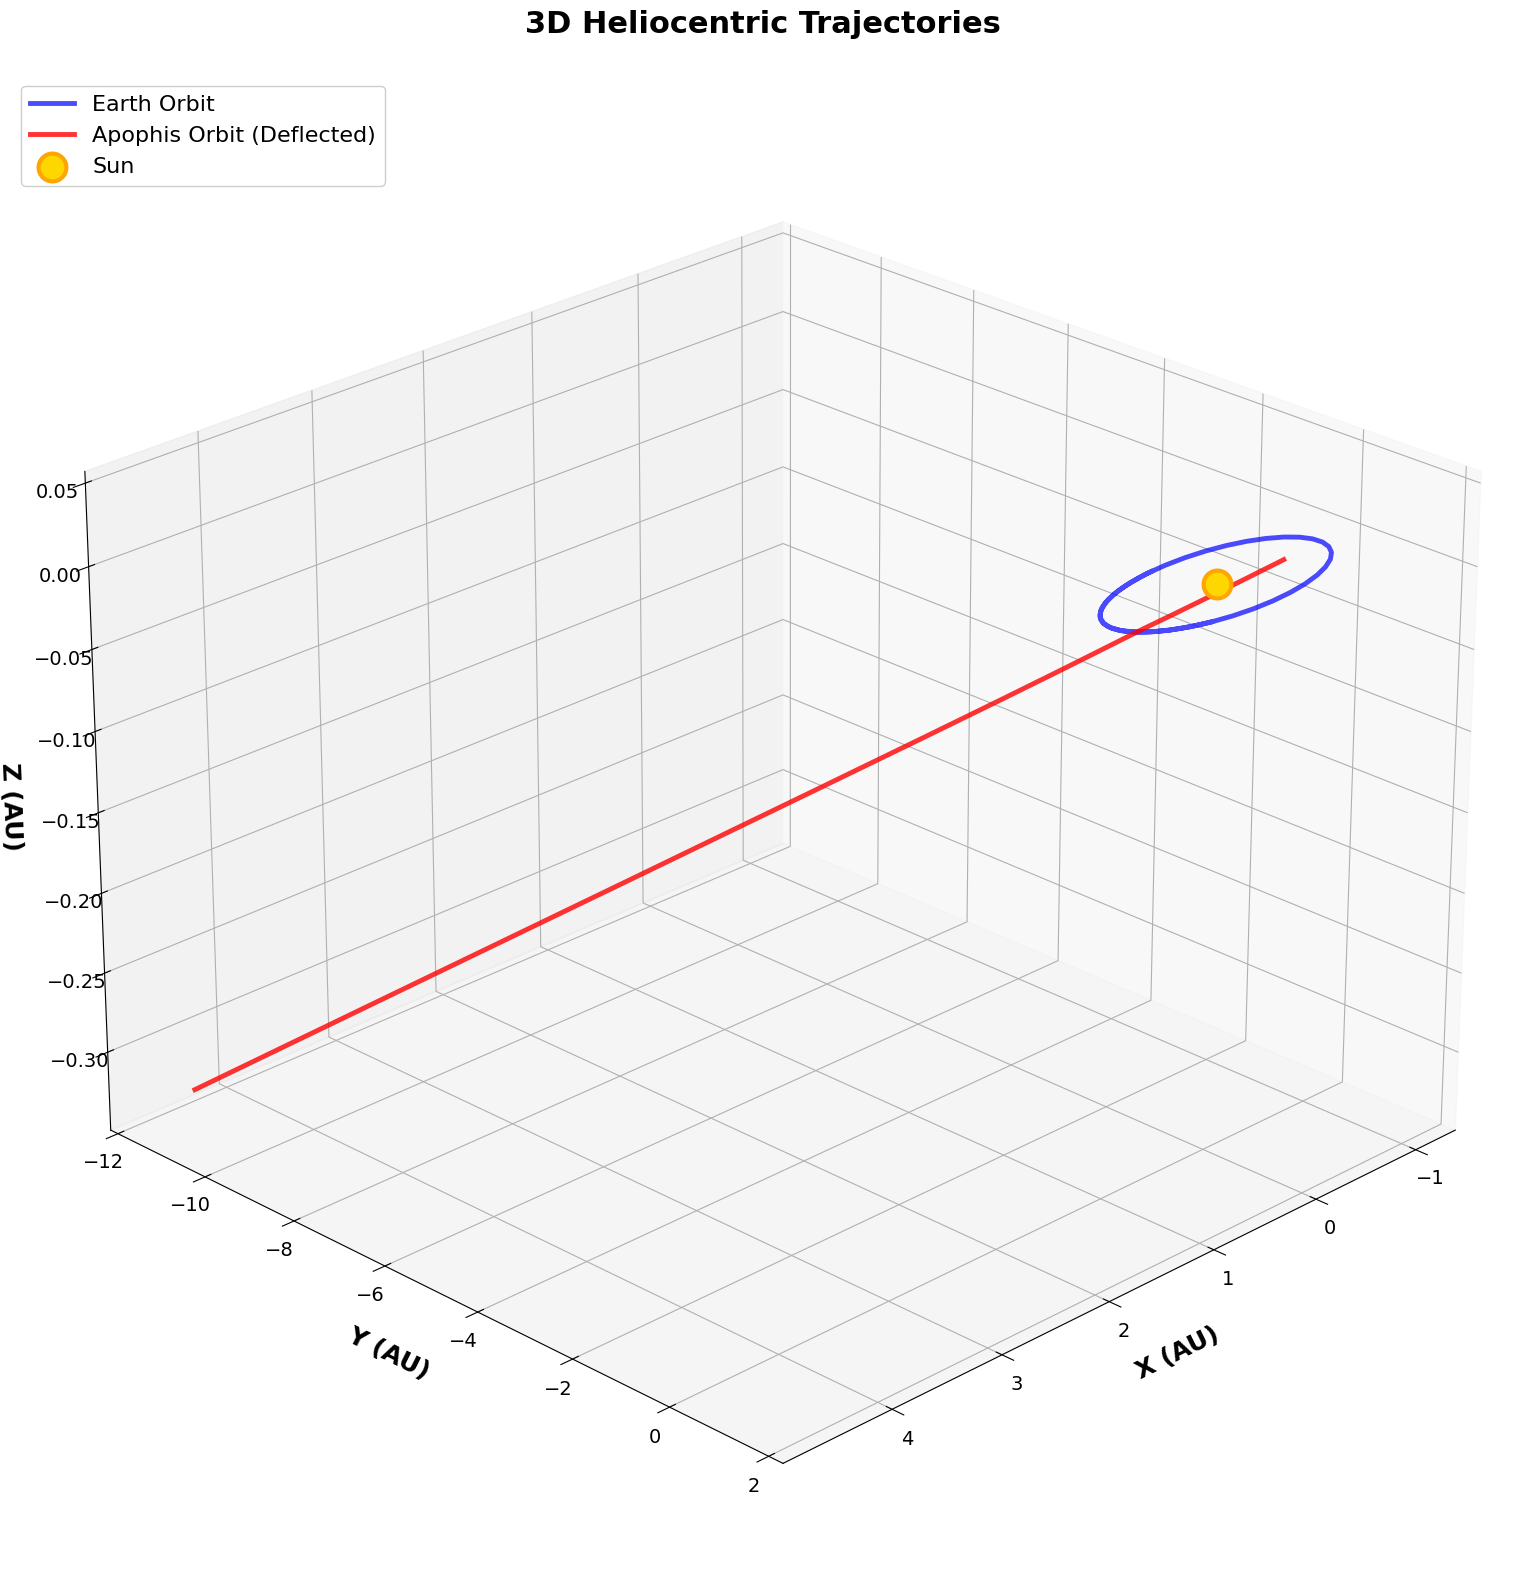

In [8]:
mission = ApophisDeflectionMission()

baseline = mission.run_scenario(0, 0.0)

opt = mission.optimize_deflection('retrograde')
final = mission.run_scenario(
    opt['impact_day'],
    opt['dv_magnitude'],
    'retrograde'
)

create_comprehensive_visualizations(final, mission)
plt.show()